In [2]:
import pandas as pd
import plotly.express as px

# Load data from CSV
df = pd.read_csv('universities.csv',sep=",",encoding='cp1252')

# Filter data for top universities (you may adjust this filter criteria)
top_universities = df[df['Rank'] <= 30]

# Create line plots for Female to Male Ratio and Research scores over different years
fig_female_male_ratio = px.line(top_universities, x='Year', y='Female to Male Ratio', color='Name', title='Female to Male Ratio Over Time')
fig_teaching_score = px.line(top_universities, x='Year', y='Teaching', color='Name', title='Teaching Score Over Time')
fig_research_environment = px.line(top_universities, x='Year', y='Research Environment', color='Name', title='Research Environment Score Over Time')
fig_research_quality = px.line(top_universities, x='Year', y='Research Quality', color='Name', title='Research Quality Score Over Time')
ratio = px.line(top_universities, x='Year', y='Rank', color='Name', title='rank')
# Display the plots
fig_female_male_ratio.show()
fig_teaching_score.show()
fig_research_environment.show()
fig_research_quality.show()
ratio.show()

Text(0.5, 0, 'Number of Universities')

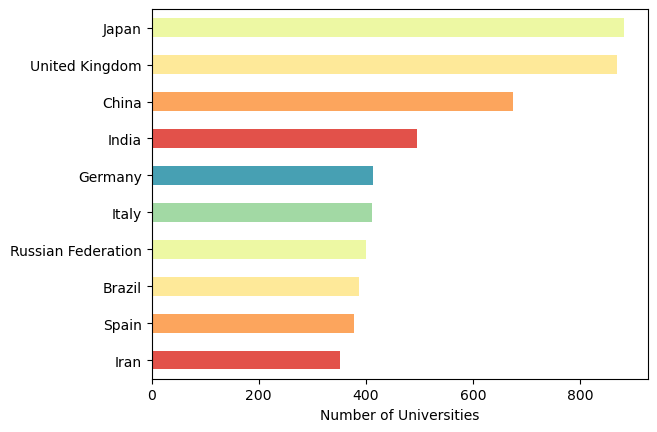

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

top_12 = df.Country.value_counts()[10:0:-1] # The first one is Unknown so I'll drop it
ax = top_12.plot(kind='barh', color=sns.color_palette('Spectral'))
ax.set_xlabel('Number of Universities')

In [4]:
import pandas as pd
import plotly.express as px

# Assuming df is your DataFrame containing university data
# Get the top 10 countries with the most universities
top_countries = df['Country'].value_counts().head(30)

# Filter the DataFrame to include only the top countries
df_top_countries = df[df['Country'].isin(top_countries.index)]

# Group universities by country and get the top 5 universities for each country
top_universities = df_top_countries.groupby('Country')['Name'].apply(lambda x: x.head(5)).reset_index()

# Create an interactive bar plot using Plotly Express
fig = px.bar(top_universities, x='Country', y=top_universities.groupby('Country').cumcount(),
             text='Name', title='Top Universities in Top 10 Countries',
             labels={'Name': 'University'}, 
             category_orders={'Country': list(top_countries.index)},
             color_discrete_sequence=px.colors.qualitative.Prism)

# Customize layout
fig.update_traces(textposition='inside', textfont_size=10)
fig.update_layout(xaxis_title='Country', yaxis_title='University', barmode='group', uniformtext_minsize=8)

# Show plot
fig.show()

In [6]:
import pandas as pd
import plotly.express as px

# Load data from CSV
df = pd.read_csv('universities.csv',sep=",",encoding='cp1252')

# Generate an interactive map using Plotly Express
fig = px.scatter_geo(df, locations='Country', locationmode='country names', color='Rank',
                     hover_name='Name', size='Student Population', projection='natural earth',
                     title='Top Universities Worldwide')
fig.show()

In [7]:
import pandas as pd
import plotly.express as px

# Load data from CSV
df = pd.read_csv('universities.csv', sep=",", encoding='cp1252')

# Filter data for universities in India
df_india = df[df['Country'] == 'India']

# Create an interactive histogram using Plotly Express
fig = px.histogram(df_india, x='Overall Score', y="Name",
                   title='Distribution of Overall Scores for Universities in India',
                   labels={'Overall Score': 'Overall Score', 'Name': 'University Name'})
fig.show()

Mean Squared Error for Harvard University: 1.9109876094068687


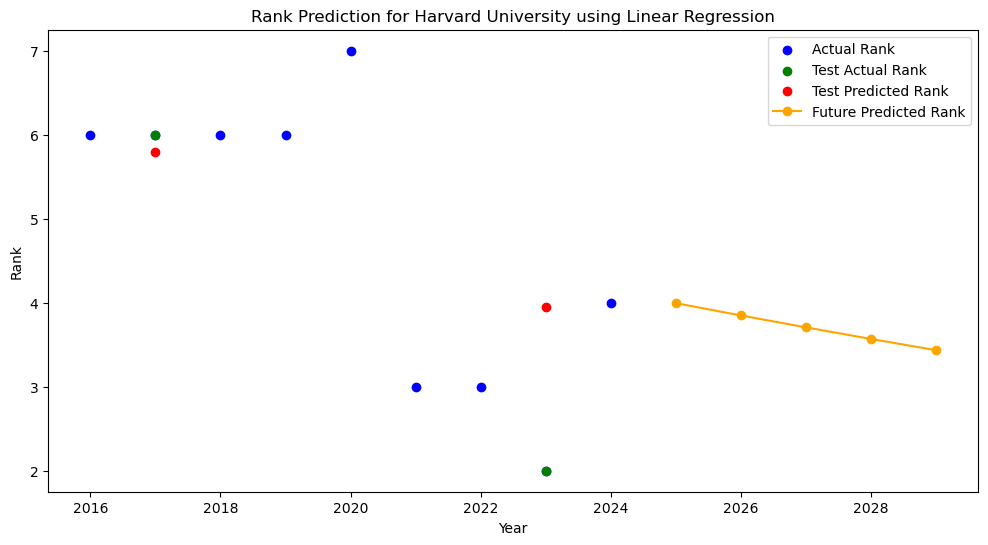

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load dataset
df = pd.read_csv('universities.csv', sep=",", encoding='cp1252')

# Select a specific college, e.g., "Harvard University"
college_name = 'Harvard University'
college_df = df[df['Name'] == college_name].copy()  # Use .copy() to avoid SettingWithCopyWarning

# Ensure there is enough data for the specific college
if len(college_df) < 2:
    raise ValueError("Not enough data for the selected college to make predictions.")

# Preprocessing
# Drop rows with missing values
college_df = college_df.dropna(subset=['Overall Score', 'Year', 'Rank'])

# Log transform the Rank to ensure positive predictions
college_df.loc[:, 'LogRank'] = np.log1p(college_df['Rank'])

# Select relevant features and target
X = college_df[['Overall Score', 'Year']]
y = college_df['LogRank']

# Train-test split (using the entire data for training due to limited data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model training
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction on the test set
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Inverse of the log1p transformation

# Evaluation
mse = mean_squared_error(np.expm1(y_test), y_pred)
print(f"Mean Squared Error for {college_name}:", mse)

# Future predictions (for the next 5 years)
future_years = np.arange(college_df['Year'].max() + 1, college_df['Year'].max() + 6).reshape(-1, 1)
future_scores = np.full((len(future_years), 1), college_df['Overall Score'].mean())
future_X = np.hstack((future_scores, future_years))

# Ensure future_X has valid feature names
future_X_df = pd.DataFrame(future_X, columns=['Overall Score', 'Year'])

future_pred_log = model.predict(future_X_df)
future_pred = np.expm1(future_pred_log)

# Visualization
plt.figure(figsize=(12, 6))
plt.scatter(college_df['Year'], college_df['Rank'], color='blue', label='Actual Rank')
plt.scatter(X_test['Year'], np.expm1(y_test), color='green', label='Test Actual Rank')
plt.scatter(X_test['Year'], y_pred, color='red', label='Test Predicted Rank')
plt.plot(future_years, future_pred, color='orange', label='Future Predicted Rank', marker='o')
plt.title(f'Rank Prediction for {college_name} using Linear Regression')
plt.xlabel('Year')
plt.ylabel('Rank')
plt.legend()
plt.show()

Mean Squared Error for California Institute of Technology: 0.2350647828276488
Mean Squared Error for University of Oxford: 0.15897859287541913
Mean Squared Error for Stanford University: 0.1109785021411821
Mean Squared Error for University of Cambridge: 4.1742966436739035
Mean Squared Error for Massachusetts Institute of Technology: 0.7127622508186517
Mean Squared Error for Harvard University: 2.5569134912533054


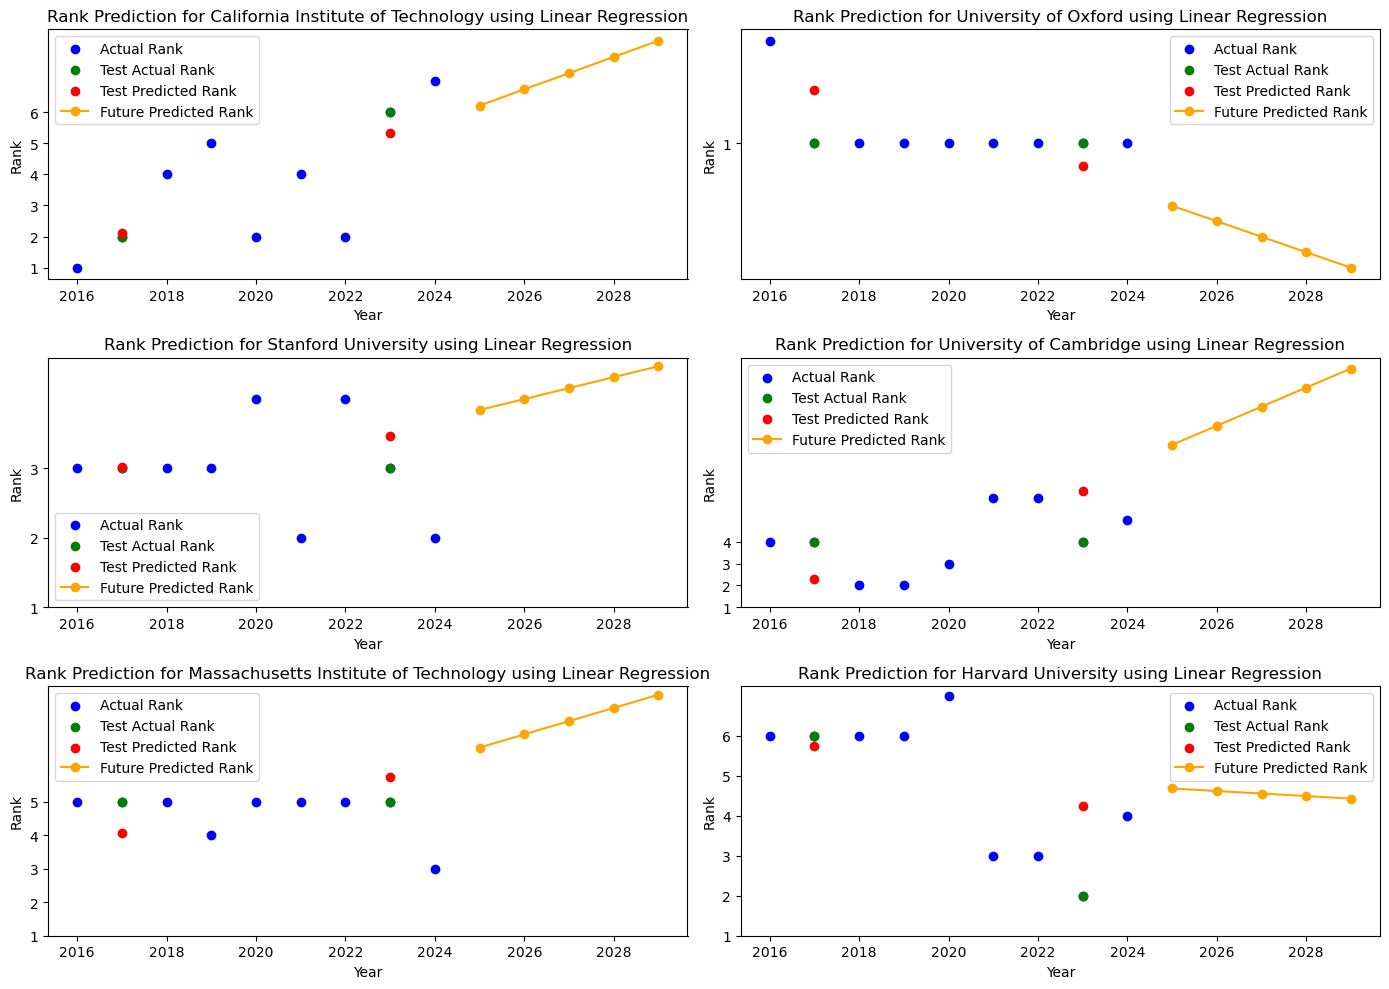

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load dataset
df = pd.read_csv('universities.csv', sep=",", encoding='cp1252')

# Get top 5 universities by rank
top_universities = df[df['Rank'] <= 5]['Name'].unique()

plt.figure(figsize=(14, 10))

for i, university in enumerate(top_universities, start=1):
    # Filter data for the specific university
    college_df = df[df['Name'] == university].copy()

    # Ensure there is enough data for the specific college
    if len(college_df) < 2:
        print(f"Not enough data for {university} to make predictions.")
        continue

    # Preprocessing
    # Drop rows with missing values
    college_df = college_df.dropna(subset=['Overall Score', 'Year', 'Rank'])

    # Select relevant features and target
    X = college_df[['Overall Score', 'Year']]
    y = college_df['Rank']  # Use 'Rank' column directly

    # Train-test split (using the entire data for training due to limited data)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Model training
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Prediction on the test set
    y_pred = model.predict(X_test)

    # Evaluation
    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean Squared Error for {university}:", mse)

    # Future predictions (for the next 5 years)
    future_years = np.arange(college_df['Year'].max() + 1, college_df['Year'].max() + 6).reshape(-1, 1)
    future_scores = np.full((len(future_years), 1), college_df['Overall Score'].mean())
    future_X = np.hstack((future_scores, future_years))

    # Ensure future_X has valid feature names
    future_X_df = pd.DataFrame(future_X, columns=['Overall Score', 'Year'])

    future_pred = model.predict(future_X_df)

    # Visualization
    plt.subplot(3, 2, i)  # Create subplots
    plt.scatter(college_df['Year'], college_df['Rank'], color='blue', label='Actual Rank')
    plt.scatter(X_test['Year'], y_test, color='green', label='Test Actual Rank')
    plt.scatter(X_test['Year'], y_pred, color='red', label='Test Predicted Rank')
    plt.plot(future_years, future_pred, color='orange', label='Future Predicted Rank', marker='o')
    plt.title(f'Rank Prediction for {university} using Linear Regression')
    plt.xlabel('Year')
    plt.ylabel('Rank')
    plt.legend()

    # Set y-axis tick labels as integers from 1 to max rank
    plt.yticks(np.arange(1, int(max(y_test)) + 1, 1))

plt.tight_layout()
plt.show()

In [17]:
pip install pandas plotly


In [21]:
import pandas as pd
import plotly.express as px


# 1. LOAD DATASET (ENCODING FIX)

df = pd.read_csv(
    "universities.csv",
    encoding="latin1"   # FIX for UnicodeDecodeError
)

print("Dataset loaded successfully")
print(df.head())
import pandas as pd
import plotly.express as px


# LOAD DATASET WITH CORRECT ENCODING

df = pd.read_csv("universities.csv", encoding="latin1")


# DATA CLEANING

df = df.dropna(subset=["Rank", "Year", "Name"])
df["Rank"] = pd.to_numeric(df["Rank"], errors="coerce")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")


# FILTER TOP 10 UNIVERSITIES

top10 = df[df["Rank"] <= 10]


# PLOT: TOP 10 UNIVERSITY RANKS OVER YEARS

fig = px.line(
    top10,
    x="Year",
    y="Rank",
    color="Name",
    markers=True,
    title="Top 10 University Ranks Over Years",
    labels={
        "Year": "Year",
        "Rank": "Rank",
        "Name": "University"
    }
)

# Reverse Rank axis (Rank 1 on top)
fig.update_yaxes(autorange="reversed")

fig.update_layout(
    legend_title="University",
    hovermode="closest",
    template="plotly_white"
)

fig.show()


Dataset loaded successfully
   Rank                                   Name         Country  \
0     1     California Institute of Technology   United States   
1     2                   University of Oxford  United Kingdom   
2     3                    Stanford University   United States   
3     4                University of Cambridge  United Kingdom   
4     5  Massachusetts Institute of Technology   United States   

   Student Population  Students to Staff Ratio International Students  \
0                2243                      6.9                    26%   
1               19920                     11.6                    34%   
2               15596                      7.8                    22%   
3               18810                     11.8                    34%   
4               11074                      9.0                    33%   

  Female to Male Ratio  Overall Score  Teaching  Research Environment  \
0              33 : 67           95.2      95.6                

In [22]:
import pandas as pd
import plotly.express as px


# 1. LOAD DATASET (ENCODING FIX)

df = pd.read_csv("universities.csv", encoding="latin1")


# 2. FILTER INDIA UNIVERSITIES

india_df = df[df["Country"] == "India"]

# Remove missing values
india_df = india_df.dropna(subset=["Rank", "Overall Score", "Year"])

# Convert Rank to numeric
india_df["Rank"] = pd.to_numeric(india_df["Rank"], errors="coerce")

# 3. FIND TOP INDIAN UNIVERSITY (BEST RANK)

top_india = india_df.loc[india_df["Rank"].idxmin()]

print("Top University in India (World Ranking Based):")
print("University Name :", top_india["Name"])
print("Best Rank       :", top_india["Rank"])
print("Year            :", top_india["Year"])
print("Overall Score   :", top_india["Overall Score"])


# 4. RANK TREND OVER YEARS

top_uni_name = top_india["Name"]
trend_df = india_df[india_df["Name"] == top_uni_name]

fig = px.line(
    trend_df,
    x="Year",
    y="Rank",
    markers=True,
    title=f"Global Rank Trend of {top_uni_name}",
    labels={"Rank": "World Rank", "Year": "Year"}
)

# Reverse rank axis
fig.update_yaxes(autorange="reversed")

fig.show()


Top University in India (World Ranking Based):
University Name : Indian Institute of Science
Best Rank       : 218
Year            : 2024
Overall Score   : 57.66


In [23]:
import pandas as pd

# ===============================
# 1. LOAD DATASET
# ===============================
df = pd.read_csv("universities.csv", encoding="latin1")

# ===============================
# 2. UNIVERSITY OF OXFORD DATA
# ===============================
oxford_df = df[df["Name"].str.contains("Oxford", case=False, na=False)]

oxford_df = oxford_df.dropna(subset=["Rank"])
oxford_df["Rank"] = pd.to_numeric(oxford_df["Rank"], errors="coerce")

best_oxford = oxford_df.sort_values("Rank").iloc[0]

print("University of Oxford Global Position")
print("-----------------------------------")
print("University :", best_oxford["Name"])
print("Country    :", best_oxford["Country"])
print("World Rank :", best_oxford["Rank"])
print("Year       :", best_oxford["Year"])

# ===============================
# 3. BEST INDIAN UNIVERSITY
# ===============================
india_df = df[df["Country"] == "India"]
india_df = india_df.dropna(subset=["Rank"])
india_df["Rank"] = pd.to_numeric(india_df["Rank"], errors="coerce")

best_india = india_df.sort_values("Rank").iloc[0]

print("\nTop Indian University (Global Ranking)")
print("-----------------------------------")
print("University :", best_india["Name"])
print("World Rank :", best_india["Rank"])

# ===============================
# 4. COMPARISON RESULT
# ===============================
print("\nComparison Result")
print("-----------------")
if best_oxford["Rank"] < best_india["Rank"]:
    print("University of Oxford ranks ABOVE all Indian universities globally.")
else:
    print("Some Indian universities rank above Oxford (very rare case).")


University of Oxford Global Position
-----------------------------------
University : University of Oxford
Country    : United Kingdom
World Rank : 1
Year       : 2020

Top Indian University (Global Ranking)
-----------------------------------
University : Indian Institute of Science
World Rank : 218

Comparison Result
-----------------
University of Oxford ranks ABOVE all Indian universities globally.


In [24]:
import pandas as pd

# ===============================
# 1. LOAD DATASET
# ===============================
df = pd.read_csv("universities.csv", encoding="latin1")

# ===============================
# 2. DATA CLEANING
# ===============================
# Remove rows with missing Rank
df = df.dropna(subset=["Rank", "Name", "Country"])

# Convert Rank to numeric
df["Rank"] = pd.to_numeric(df["Rank"], errors="coerce")

# Remove invalid ranks
df = df.dropna(subset=["Rank"])

# ===============================
# 3. SORT UNIVERSITIES BY RANK
# ===============================
rankwise_list = df.sort_values("Rank")

# ===============================
# 4. DISPLAY TOP RESULTS
# ===============================
print("Overall University Rank-Wise List (Top 20)")
print("------------------------------------------")

print(
    rankwise_list[["Rank", "Name", "Country", "Year", "Overall Score"]]
    .head(20)
    .to_string(index=False)
)


Overall University Rank-Wise List (Top 20)
------------------------------------------
 Rank                               Name        Country  Year  Overall Score
    1 California Institute of Technology  United States  2016        95.2000
    1               University of Oxford United Kingdom  2024        98.4575
    1               University of Oxford United Kingdom  2019        96.0175
    1               University of Oxford United Kingdom  2017        95.0200
    1               University of Oxford United Kingdom  2023        96.3875
    1               University of Oxford United Kingdom  2020        95.4175
    1               University of Oxford United Kingdom  2022        95.6625
    1               University of Oxford United Kingdom  2021        95.6175
    1               University of Oxford United Kingdom  2018        94.3075
    2                Stanford University  United States  2021        94.8550
    2                Stanford University  United States  2024      

In [25]:
rankwise_list.to_csv("overall_university_rankwise_list.csv", index=False)
print("Rank-wise list saved successfully.")


Rank-wise list saved successfully.


In [26]:
#OVERALL WORLD UNIVERSITY ANALYSIS BY RANK WISE OVERALL SCORE
import pandas as pd


df = pd.read_csv("universities.csv", encoding="latin1")


df = df[["Rank", "Name", "Country", "Year", "Overall Score"]]


df = df.dropna(subset=["Rank", "Name"])


df["Rank"] = pd.to_numeric(df["Rank"], errors="coerce")


df = df.dropna(subset=["Rank"])


world_rankwise = df.sort_values("Rank")


print("🌍 Overall World University Rank-Wise List (Top 50)")
print("--------------------------------------------------")

print(
    world_rankwise
    .head(50)
    .to_string(index=False)
)


🌍 Overall World University Rank-Wise List (Top 50)
--------------------------------------------------
 Rank                                  Name        Country  Year  Overall Score
    1    California Institute of Technology  United States  2016        95.2000
    1                  University of Oxford United Kingdom  2024        98.4575
    1                  University of Oxford United Kingdom  2019        96.0175
    1                  University of Oxford United Kingdom  2017        95.0200
    1                  University of Oxford United Kingdom  2023        96.3875
    1                  University of Oxford United Kingdom  2020        95.4175
    1                  University of Oxford United Kingdom  2022        95.6625
    1                  University of Oxford United Kingdom  2021        95.6175
    1                  University of Oxford United Kingdom  2018        94.3075
    2                   Stanford University  United States  2021        94.8550
    2             